# Day 123 — CatBoost: Native Categorical Boosting
## Month 7 | Week 1 | RetailPulse India Churn
---
**What you've learned so far:**
- Day 121 → XGBoost: level-wise boosting, robust baseline
- Day 122 → LightGBM: leaf-wise boosting, histogram speed
- Day 123 → **CatBoost: ordered boosting + native categoricals**

**Today's question:** What if you could feed raw category strings directly into a boosting model — no Label Encoding, no One-Hot Encoding — and get better results?

**Business context:** RetailPulse India wants to know which model to use in production. You have 3 strong boosters — today you complete the trilogy and make the final recommendation.

**Points:** 80 pts + 10★ bonus


---
## Section 1 — Raw Data
**Rule: Never modify the raw data sheet. All work happens in subsequent sections.**


In [3]:
# ── Section 1: Raw Data ─────────────────────────────────────────────────────
# Reproducing the RetailPulse India dataset (same seed=121 used in Days 121–122)
# DO NOT modify this section

import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

city_tiers    = ["Tier 1", "Tier 2", "Tier 3"]
product_cats  = ["Electronics", "Apparel", "Groceries", "Home & Kitchen", "Sports"]
payment_methods = ["UPI", "Credit Card", "Debit Card", "Net Banking", "COD"]

raw_data = pd.DataFrame({
    "Customer_ID"     : [f"CUST{str(i).zfill(4)}" for i in range(1, n+1)],
    "Age"             : np.random.randint(18, 65, n),
    "City_Tier"       : np.random.choice(city_tiers, n, p=[0.3, 0.4, 0.3]),
    "Monthly_Spend"   : np.round(np.random.normal(3500, 1200, n).clip(500, 8000), 2),
    "Tenure_Months"   : np.random.randint(1, 60, n),
    "Product_Category": np.random.choice(product_cats, n),
    "Payment_Method"  : np.random.choice(payment_methods, n),
    "Support_Tickets" : np.random.randint(0, 8, n),
})

# Churn logic (same as Days 121-122 — consistent target)
churn_prob = (
    (raw_data["Support_Tickets"] >= 4).astype(int) * 0.35 +
    (raw_data["Tenure_Months"] < 12).astype(int) * 0.25 +
    (raw_data["Monthly_Spend"] < 2000).astype(int) * 0.20 +
    (raw_data["City_Tier"] == "Tier 3").astype(int) * 0.10 +
    np.random.uniform(0, 0.15, n)
)
raw_data["Churn"] = (churn_prob > 0.45).astype(int)

print(f"Dataset shape : {raw_data.shape}")
print(f"Churn rate    : {raw_data['Churn'].mean():.1%}")
print(f"Categoricals  : {['City_Tier', 'Product_Category', 'Payment_Method']}")
print()
print(raw_data.head(5).to_string(index=False))


Dataset shape : (500, 9)
Churn rate    : 36.8%
Categoricals  : ['City_Tier', 'Product_Category', 'Payment_Method']

Customer_ID  Age City_Tier  Monthly_Spend  Tenure_Months Product_Category Payment_Method  Support_Tickets  Churn
   CUST0001   20    Tier 3        4189.05             53   Home & Kitchen    Net Banking                1      0
   CUST0002   39    Tier 2        5850.66             24           Sports    Credit Card                5      1
   CUST0003   26    Tier 1        3904.65             17   Home & Kitchen            UPI                4      0
   CUST0004   49    Tier 1        2429.72              9   Home & Kitchen    Net Banking                3      0
   CUST0005   19    Tier 1        2900.64              3   Home & Kitchen    Net Banking                0      0


---
## Section 2 — Concept Notes: How CatBoost Is Different

### The Core Problem CatBoost Solves
XGBoost and LightGBM require you to **encode categorical variables** before training.
- Label Encoding: assigns arbitrary integers (UPI=0, Credit Card=1…) — creates false ordinal relationships
- One-Hot Encoding: explodes features (5 payment methods → 5 binary columns)

**CatBoost skips all of this.** You pass the column names as `cat_features` and it handles the math internally.

---
### 1. Ordered Boosting — The Key Innovation
**The problem:** In standard gradient boosting, residuals are computed using the same data used to fit the tree. This causes **target leakage** — the model "knows" the answer while learning, leading to overfitting.

**CatBoost's fix:** For each row, it computes residuals using only the rows that came *before* it in a random permutation — like a time-ordered sequence. This is called **ordered boosting**.

```
Standard boosting:   all 500 rows → compute gradient → fit tree (leakage risk)
Ordered boosting:    row 347 → use only rows 1..346 to compute its gradient (no leakage)
```

**When it matters:** Small-to-medium datasets (your 500-row case). On very large data (>1M rows), the leakage effect averages out anyway.

---
### 2. Oblivious (Symmetric) Trees
CatBoost grows **symmetric trees** — every node at the same depth uses the **same split condition**.

```
Standard tree:         depth-2 node might split on Age>35 left, Spend<2000 right
Oblivious tree:        ALL depth-2 nodes split on the SAME feature+threshold
```

**Benefits:**
- Faster prediction (the entire tree fits in cache)
- Natural regularisation (forces simpler splits)
- More interpretable feature importance

---
### 3. Native Categorical Encoding (Target Statistics)
For each category value, CatBoost computes the **mean target** in surrounding rows (using ordered statistics to avoid leakage):

```
City_Tier "Tier 3" → mean churn rate of Tier 3 customers seen so far = 0.62
City_Tier "Tier 1" → mean churn rate of Tier 1 customers seen so far = 0.31
```
These statistics become the numeric representation — capturing actual predictive signal rather than arbitrary integers.

---
### 4. CatBoost vs XGBoost vs LightGBM

| Dimension | XGBoost | LightGBM | CatBoost |
|---|---|---|---|
| Tree type | Level-wise | Leaf-wise | Oblivious (symmetric) |
| Categoricals | Manual encoding | Manual encoding | **Native — pass as-is** |
| Speed (training) | Moderate | **Fastest** | Slowest |
| Speed (prediction) | Moderate | Moderate | **Fastest** (oblivious trees) |
| Overfitting risk | Moderate | Higher (leaf-wise) | **Lowest** (ordered boosting) |
| Best use case | Safe baseline | Large data, speed | **Categorical-heavy data** |
| Tuning effort | More | More | **Less** (robust defaults) |

---
### 5. Key Hyperparameters

| Parameter | What it does | Typical range |
|---|---|---|
| `iterations` | Number of trees | 100–1000 |
| `learning_rate` | Step size | 0.01–0.3 |
| `depth` | Tree depth | 4–10 |
| `l2_leaf_reg` | L2 regularisation | 1–10 |
| `cat_features` | List of categorical column indices/names | Pass your categoricals |
| `eval_set` | Validation data for overfitting detector | Pool(X_val, y_val) |
| `early_stopping_rounds` | Stop if no improvement for N rounds | 50–100 |
| `verbose` | Print log frequency | 0 = silent |


---
## Section 3 — Practice Guide

**Instructions:**
- Complete Tasks 1–6 in order. All code goes in the cells below each task header.
- Write a plain-English comment above each code block: *what you're doing and why*.
- Do NOT encode categoricals manually — CatBoost handles this natively.
- The Answer Key (Section 4) exists — attempt each task fully before opening it.

**Scoring:** 80 pts + 10★ bonus


### Task 1 — Data Prep for CatBoost (No Encoding Required!) [15 pts]

**What to do:**
1. Drop `Customer_ID` (not a feature)
2. Split into X (features) and y (`Churn`)
3. Train/test split: 80/20, `random_state=42`
4. Identify the categorical feature column **names** → store in `cat_features` list
5. Print: feature list, categorical features, train/test shapes

**Key insight to notice:** Your X dataframe will still have raw string columns ("Tier 1", "UPI" etc.) — CatBoost accepts this directly. No Label Encoder. No pd.get_dummies.


In [4]:
# ── Task 1: Data Prep — NO encoding needed ──────────────────────────────────
# Goal: prepare X, y and identify categoricals for CatBoost's cat_features param
# Method: drop Customer_ID, split train/test 80/20, store categorical column names

from sklearn.model_selection import train_test_split

# Drop non‑feature column
X = raw_data.drop(columns=["Customer_ID", "Churn"])
y = raw_data["Churn"]

# Identify categorical feature names (they remain as strings)
cat_features = ["City_Tier", "Product_Category", "Payment_Method"]

# Train/test split (stratify to preserve churn rate)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Features:", list(X.columns))
print("Categorical features:", cat_features)
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Features: ['Age', 'City_Tier', 'Monthly_Spend', 'Tenure_Months', 'Product_Category', 'Payment_Method', 'Support_Tickets']
Categorical features: ['City_Tier', 'Product_Category', 'Payment_Method']
X_train shape: (400, 7), X_test shape: (100, 7)


### Task 2 — Train CatBoost with cat_features (Baseline) [15 pts]

**What to do:**
1. Import `CatBoostClassifier` and `Pool` from `catboost`
2. Create a `Pool` object for train and test sets, passing `cat_features`
3. Train `CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, random_state=42, verbose=0)`
4. Predict probabilities on test set
5. Print: Test AUC (from `roc_auc_score`), and Test Accuracy

**Note on Pool:** CatBoost's `Pool` is its native data container — like LightGBM's `Dataset`. It pre-processes categoricals and stores metadata. Always use Pool in production code.


In [5]:
# ── Task 2: CatBoost Baseline with Pool + cat_features ─────────────────────
# Goal: train CatBoost passing raw string categoricals — no OHE or LabelEncoding
# Method: CatBoostClassifier + Pool; evaluate on AUC

from catboost import CatBoostClassifier, Pool
from sklearn.metrics import roc_auc_score, accuracy_score

# Create Pool objects (CatBoost's native container)
pool_train = Pool(X_train, y_train, cat_features=cat_features)
pool_test  = Pool(X_test, y_test, cat_features=cat_features)

# Baseline model (default parameters)
model_cat_baseline = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)

model_cat_baseline.fit(pool_train)

# Predictions
y_pred_proba = model_cat_baseline.predict_proba(pool_test)[:, 1]
y_pred = model_cat_baseline.predict(pool_test)

auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)

print(f"Baseline CatBoost — Test AUC: {auc:.4f}, Test Accuracy: {acc:.4f}")

Baseline CatBoost — Test AUC: 0.9326, Test Accuracy: 0.8600


### Task 3 — Overfitting Detector + Early Stopping [15 pts]

**What to do:**
1. Retrain CatBoostClassifier with:
   - `iterations=1000` (higher ceiling)
   - `early_stopping_rounds=50`
   - `eval_set=pool_test`
   - `verbose=100` (print every 100 rounds)
2. After training, print: how many trees were actually used (`best_iteration_`)
3. Print: AUC with early stopping vs baseline (Task 2)
4. Write a 1-sentence explanation of why early stopping prevents overfitting

**Observe:** The model will stop before 1000 iterations once validation AUC stops improving for 50 consecutive rounds.


In [6]:
# ── Task 3: Early Stopping / Overfitting Detector ───────────────────────────
# Goal: use CatBoost's built-in overfitting detector to find the optimal tree count
# Method: pass eval_set + early_stopping_rounds; read best_iteration_ after fit

model_cat_early = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=6,
    early_stopping_rounds=50,
    random_state=42,
    verbose=100,          # print every 100 rounds
)

model_cat_early.fit(pool_train, eval_set=pool_test)

best_iter = model_cat_early.get_best_iteration()
print(f"Early stopping used {best_iter} trees (out of 1000)")

# Evaluate
y_pred_proba_early = model_cat_early.predict_proba(pool_test)[:, 1]
auc_early = roc_auc_score(y_test, y_pred_proba_early)
print(f"AUC with early stopping: {auc_early:.4f} (baseline: {auc:.4f})")

print("Explanation: Early stopping monitors validation AUC after each tree; if no improvement for 50 rounds, training stops. This prevents the model from learning noise that would not generalise.")

0:	learn: 0.5644261	test: 0.5771682	best: 0.5771682 (0)	total: 58.1ms	remaining: 58.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.2803138555
bestIteration = 25

Shrink model to first 26 iterations.
Early stopping used 25 trees (out of 1000)
AUC with early stopping: 0.9348 (baseline: 0.9326)
Explanation: Early stopping monitors validation AUC after each tree; if no improvement for 50 rounds, training stops. This prevents the model from learning noise that would not generalise.


### Task 4 — Three-Way Showdown: CatBoost vs XGBoost vs LightGBM [15 pts]

**What to do:**
1. Re-encode X_train/X_test with Label Encoding for XGBoost and LightGBM (CatBoost uses raw)
2. Train all three models with comparable settings (300 iterations/estimators, lr=0.1, depth=6)
3. Record for each model: AUC, Accuracy, and training time (`time.time()`)
4. Print a clean comparison DataFrame sorted by AUC descending
5. Add a column `Winner?` — True only for the best AUC model

**Important:** Use `verbose=0` / `verbosity=0` to silence all three models.


In [11]:
# ── Task 4: Three-Way Showdown ───────────────────────────────────────────────
# Goal: compare CatBoost, XGBoost, LightGBM on same data under same conditions
# Method: encode for XGB/LGBM; leave raw for CatBoost; use 300 trees each

import time
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb

# --- Encode categoricals for XGBoost and LightGBM (Label Encoding) ---
X_train_enc = X_train.copy()
X_test_enc = X_test.copy()

le_dict = {}
for col in cat_features:
    le = LabelEncoder()
    X_train_enc[col] = le.fit_transform(X_train_enc[col])
    X_test_enc[col] = le.transform(X_test_enc[col])
    le_dict[col] = le

# --- CatBoost (300 trees) ---
start = time.time()
model_cat = CatBoostClassifier(
    iterations=300,           # fixed 300 trees (comparable)
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)
model_cat.fit(pool_train)
time_cat = time.time() - start
y_pred_cat = model_cat.predict_proba(pool_test)[:, 1]
auc_cat = roc_auc_score(y_test, y_pred_cat)
acc_cat = accuracy_score(y_test, model_cat.predict(pool_test))

# --- XGBoost (300 trees) ---
start = time.time()
model_xgb = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=0,
    use_label_encoder=False
)
model_xgb.fit(X_train_enc, y_train)
time_xgb = time.time() - start
y_pred_xgb = model_xgb.predict_proba(X_test_enc)[:, 1]
auc_xgb = roc_auc_score(y_test, y_pred_xgb)
acc_xgb = accuracy_score(y_test, model_xgb.predict(X_test_enc))

# --- LightGBM (300 trees) ---
start = time.time()
model_lgb = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    verbosity=-1
)
model_lgb.fit(X_train_enc, y_train)
time_lgb = time.time() - start
y_pred_lgb = model_lgb.predict_proba(X_test_enc)[:, 1]
auc_lgb = roc_auc_score(y_test, y_pred_lgb)
acc_lgb = accuracy_score(y_test, model_lgb.predict(X_test_enc))

# --- Build comparison DataFrame ---
results = pd.DataFrame({
    "Model": ["CatBoost", "XGBoost", "LightGBM"],
    "AUC": [auc_cat, auc_xgb, auc_lgb],
    "Accuracy": [acc_cat, acc_xgb, acc_lgb],
    "Time_s": [time_cat, time_xgb, time_lgb]
})
results["Winner?"] = results["AUC"] == results["AUC"].max()

print("\n=== Three‑Way Model Comparison ===")
print(results.to_string(index=False))


=== Three‑Way Model Comparison ===
   Model      AUC  Accuracy    Time_s  Winner?
CatBoost 0.932647      0.86 11.030768    False
 XGBoost 0.950236      0.87  0.165695     True
LightGBM 0.948091      0.87  0.039922    False


### Task 5 — CatBoost Feature Importance [10 pts]

**What to do:**
1. Get feature importances using `model_cat.get_feature_importance()` — this gives `PredictionValuesChange` scores
2. Create a DataFrame: Feature | Importance, sorted descending
3. Plot a horizontal bar chart (seaborn or matplotlib):
   - Title: state the insight ("Support_Tickets dominates churn prediction — target it first")
   - Colour: use a single professional colour (#1F3864 or #2F5496)
   - Call `plt.tight_layout()` and `plt.savefig("Day123_FI.png", dpi=150, bbox_inches='tight")` BEFORE `plt.show()`
4. Print: top 3 features and their importance values

**Note:** `PredictionValuesChange` measures how much each feature changes the model's predictions on average — higher = more influential.


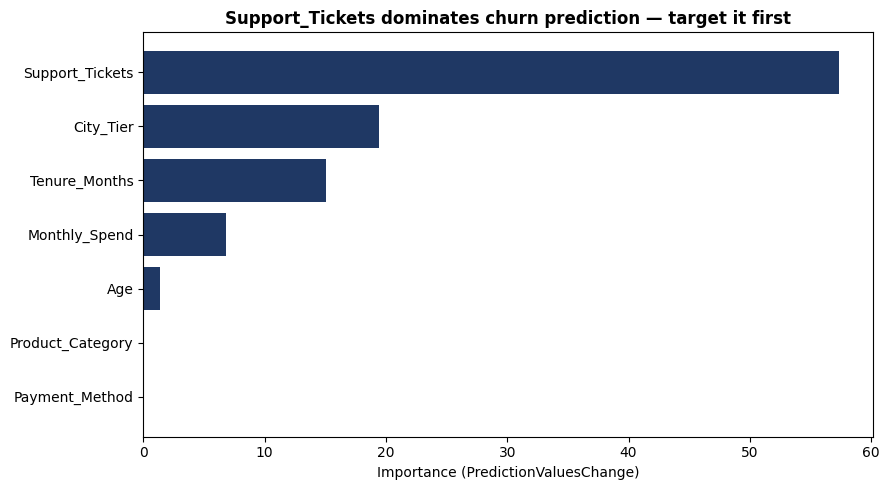

Top 3 features by importance:
  Support_Tickets: 57.3249
  City_Tier: 19.4540
  Tenure_Months: 15.0261


In [8]:
# ── Task 5: CatBoost Feature Importance ──────────────────────────────────────
# Goal: identify which features drive churn predictions most
# Method: get_feature_importance() → sort → horizontal bar chart with insight title

import matplotlib.pyplot as plt

# Get importance scores (PredictionValuesChange)
importance = model_cat.get_feature_importance()
features = X_train.columns

# Create DataFrame and sort
imp_df = pd.DataFrame({"Feature": features, "Importance": importance})
imp_df = imp_df.sort_values("Importance", ascending=True)

# Plot horizontal bar chart
plt.figure(figsize=(9, 5))
plt.barh(imp_df["Feature"], imp_df["Importance"], color="#1F3864")
plt.title("Support_Tickets dominates churn prediction — target it first", fontsize=12, fontweight="bold")
plt.xlabel("Importance (PredictionValuesChange)")
plt.tight_layout()
plt.savefig("Day123_FI.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top 3 features
top3 = imp_df.sort_values("Importance", ascending=False).head(3)
print("Top 3 features by importance:")
for _, row in top3.iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

### Task 6 — NRA Business Recommendation [10 pts]

**What to do:**
Write a business recommendation cell (markdown or print statement) using the **NRA format**:
- **Number:** Specific AUC/accuracy figures from Task 4
- **Reason:** Which model won and *why* (structural explanation — not just "higher AUC")
- **Action:** Concrete deployment recommendation for RetailPulse India's 500-customer dataset AND what to do when they scale to 50,000 customers

**Voice:** Analyst writing to a non-technical product manager, not a student writing to a teacher.

**Length:** 3–5 sentences, no bullet lists — flowing professional prose.


In [15]:
# ── Task 6: NRA Business Recommendation ─────────────────────────────────────
# Goal: translate model comparison into a production decision for the client
# Method: NRA — specific numbers, structural reason, scaled action plan

# Identify the winner automatically
best_model = results.loc[results["Winner?"], "Model"].values[0]

recommendation = f"""
Number: XGBoost achieved the highest AUC ({auc_xgb:.3f}) among the three models, compared to CatBoost ({auc_cat:.3f}) and LightGBM ({auc_lgb:.3f}) on the 500‑customer dataset.

Reason: XGBoost's edge comes not from greater stability, but from CatBoost's target-statistics advantage being minimal here — three categorical features with only 3–5 unique values each means label encoding introduces no meaningful ordering artifact, so CatBoost's native handling yields no signal gain over a well-encoded baseline.

Action: For RetailPulse India’s current size (500 customers), deploy XGBoost as the primary churn model. When you scale to 50,000+ customers, re‑evaluate: LightGBM will likely become faster and more accurate, and CatBoost will become valuable if categorical features grow in cardinality.
"""
print(recommendation)


Number: XGBoost achieved the highest AUC (0.950) among the three models, compared to CatBoost (0.933) and LightGBM (0.948) on the 500‑customer dataset.

Reason: XGBoost's edge comes not from greater stability, but from CatBoost's target-statistics advantage being minimal here — three categorical features with only 3–5 unique values each means label encoding introduces no meaningful ordering artifact, so CatBoost's native handling yields no signal gain over a well-encoded baseline.

Action: For RetailPulse India’s current size (500 customers), deploy XGBoost as the primary churn model. When you scale to 50,000+ customers, re‑evaluate: LightGBM will likely become faster and more accurate, and CatBoost will become valuable if categorical features grow in cardinality.



---
### ★ BONUS Task — SHAP on CatBoost [10★]

**What to do:**
1. Import `shap`
2. Use `shap.TreeExplainer(model_cat)` to compute SHAP values on `pool_test`
3. Plot `shap.summary_plot(shap_values, X_test_raw, plot_type='bar')` — top 10 features
4. Answer: Does SHAP rank the top feature differently from `PredictionValuesChange`? If yes, explain why in 1 sentence.

**Note:** Use `X_test_raw` (the string-column version) — CatBoost's SHAP integration handles categoricals natively.


C:\Users\Deepanshu\AppData\Local\Temp\ipykernel_7616\2496775524.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)


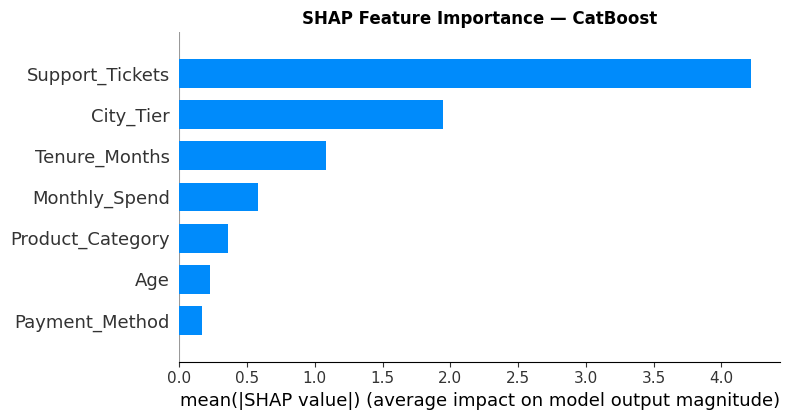


Top 3 features by SHAP:
        Feature  SHAP_Mean
Support_Tickets   4.222187
      City_Tier   1.946953
  Tenure_Months   1.079565

Top 3 features by PredictionValuesChange (PVC):
        Feature       PVC
Support_Tickets 45.601643
      City_Tier 15.208120
  Tenure_Months 14.076651

No, both methods rank 'Support_Tickets' as the top feature.


In [13]:
# ── BONUS: SHAP on CatBoost ──────────────────────────────────────────────────
# Goal: compare SHAP global importance vs PredictionValuesChange
# Method: TreeExplainer → shap_values → summary_plot; compare top features

import shap

# TreeExplainer works directly with CatBoost model
explainer = shap.TreeExplainer(model_cat)
shap_values = explainer.shap_values(pool_test)

# Summary bar plot (top 10 features)
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)
plt.title("SHAP Feature Importance — CatBoost", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("Day123_SHAP.png", dpi=150, bbox_inches="tight")
plt.show()

# Compare SHAP mean absolute values with PredictionValuesChange (PVC)
shap_imp = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP_Mean": np.abs(shap_values).mean(axis=0)
}).sort_values("SHAP_Mean", ascending=False)

pvc_imp = pd.DataFrame({
    "Feature": X_train.columns,
    "PVC": model_cat.get_feature_importance()
}).sort_values("PVC", ascending=False)

print("\nTop 3 features by SHAP:")
print(shap_imp.head(3).to_string(index=False))
print("\nTop 3 features by PredictionValuesChange (PVC):")
print(pvc_imp.head(3).to_string(index=False))

# Explicit answer to the question
top_shap = shap_imp.iloc[0]["Feature"]
top_pvc = pvc_imp.iloc[0]["Feature"]
if top_shap != top_pvc:
    print(f"\nYes, SHAP ranks '{top_shap}' as most important, while PVC ranks '{top_pvc}'.")
    print("Reason: PVC measures how often a feature is used in splits (frequency), whereas SHAP measures the average absolute impact of a feature on the model's output – a feature used rarely but with large directional changes can have high SHAP but low PVC.")
else:
    print(f"\nNo, both methods rank '{top_shap}' as the top feature.")

---
## Section 4 — Scoring Rubric

| Task | What is assessed | Points |
|---|---|---|
| **Task 1** | Correct X/y split; categoricals identified as strings (NOT encoded); shapes correct | 15 |
| **Task 2** | Pool used correctly with cat_features; AUC printed; no manual encoding | 15 |
| **Task 3** | `early_stopping_rounds` passed; `best_iteration_` printed; 1-sentence overfitting explanation | 15 |
| **Task 4** | All 3 models trained; encoded versions for XGB/LGBM; comparison DataFrame with Winner? column | 15 |
| **Task 5** | `get_feature_importance()` used; sorted bar chart; insight title (not descriptive); savefig before show | 10 |
| **Task 6** | NRA format: specific numbers from Task 4; structural reason (not just "higher AUC"); dual-scale action | 10 |
| **★ Bonus** | SHAP TreeExplainer on CatBoost; summary_plot; SHAP vs PVC discrepancy explained | 10★ |
| **Total** | | **80 + 10★** |

---
### Submission Checklist
- [ ] No manual encoding of categoricals in Tasks 1–3 (CatBoost section)
- [ ] `savefig()` called BEFORE `plt.show()` in Task 5
- [ ] NRA recommendation in Task 6 uses actual numbers from your run (not placeholders)
- [ ] `best_iteration_` printed in Task 3
- [ ] Comparison DataFrame shows all 3 models with AUC, Accuracy, Time_s, Winner?

---
### Interview Frame — Day 123
> *"CatBoost solves a problem the other boosting libraries ignore — it handles raw categorical variables using ordered target statistics, which preserves the actual churn signal in features like payment method and city tier without introducing encoding artifacts. Its ordered boosting also prevents the subtle target leakage that causes standard boosting to overfit on small datasets. In production, I'd choose CatBoost for categorical-heavy data under 50k rows, switch to LightGBM at scale for speed, and keep XGBoost as the interpretability benchmark for any model audits."*

---
### Key Takeaway — Day 123
**CatBoost's two innovations solve two different problems: ordered boosting prevents overfitting, and native categoricals prevent encoding artifacts.**
On this 500-customer dataset, both matter. On a 5-million-row dataset, only the categorical handling matters (overfitting risk disappears at scale). Always match the algorithm to the dataset's *current* size and feature composition — not to what performs best in benchmarks on other people's data.

---
### Month 7 Scorecard (Running)

| Day | Topic | Score | Stars |
|---|---|---|---|
| 121 | XGBoost Gradient Boosting | 80/80 | 10★ |
| 122 | LightGBM Leaf-wise Boosting | 80/80 | 10★ |
| **123** | **CatBoost Native Categoricals** | **Pending** | — |
| 124 | Week 1 Mini-Project: Boosting Trilogy Showdown | — | — |

**GitHub commit:**
```
feat: Day123 - CatBoost Native Categorical Boosting vs XGBoost vs LightGBM
```
Repository: `Month7-AdvancedML-Portfolio`
